# PremierLeagueML: EDA, modelos predictivos y dashboard academico

Este notebook documenta el flujo completo del proyecto `PremierLeagueML` con un enfoque de entrega academica. El objetivo es analizar partidos y eventos de la Premier League, construir un modelo de **xG con regresion logistica**, una **regresion lineal para goles totales** y un **predictor multiclase H/D/A**, y finalmente exportar resultados reproducibles hacia un dashboard estatico.

La narrativa esta organizada en cinco bloques: carga de datos, EDA, modelo xG, predictor de partidos y exportacion final. En cada visualizacion se explica que muestra, por que importa y que hallazgo aporta a la interpretacion del proyecto.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

from pipeline import (
    load_datasets,
    prepare_match_model_data,
    prepare_xg_shots,
    run_pipeline,
    train_match_models,
    train_xg_model,
)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12


## 1. Carga de datos

La base del proyecto esta compuesta por tres archivos:

- `matches.csv`: informacion a nivel partido, marcador final, cuotas y metadatos.
- `events.csv`: eventos de juego a nivel accion, incluyendo coordenadas de disparo.
- `players.csv`: catalogo de jugadores.

La consistencia del proyecto depende de trabajar con el esquema real del dataset. Por eso el modelo xG se apoya en geometria del disparo y no inventa columnas ausentes, como `qualifiers`, que no forman parte del archivo de eventos disponible.

In [2]:
players, matches, events = load_datasets()
shots = prepare_xg_shots(events)
match_data = prepare_match_model_data(matches)

print(f"Jugadores: {players.shape}")
print(f"Partidos: {matches.shape}")
print(f"Eventos: {events.shape}")
print(f"Disparos modelables: {shots.shape}")
print(f"Partidos para predictor: {match_data.shape}")


Jugadores: (822, 37)
Partidos: (291, 41)
Eventos: (444252, 19)
Disparos modelables: (7198, 24)
Partidos para predictor: (291, 42)


## 2. EDA: comportamiento general de goles y resultados

Estas visualizaciones introducen la estructura de la muestra antes de modelar. El objetivo es entender como se distribuyen los goles y como se reparte la variable objetivo H/D/A.

C:\Users\User\AppData\Local\Temp\ipykernel_17116\1059298227.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=result_counts.index, y=result_counts.values, palette=["#0e6b5c", "#c48a2c", "#d86d3e"], ax=axes[1])


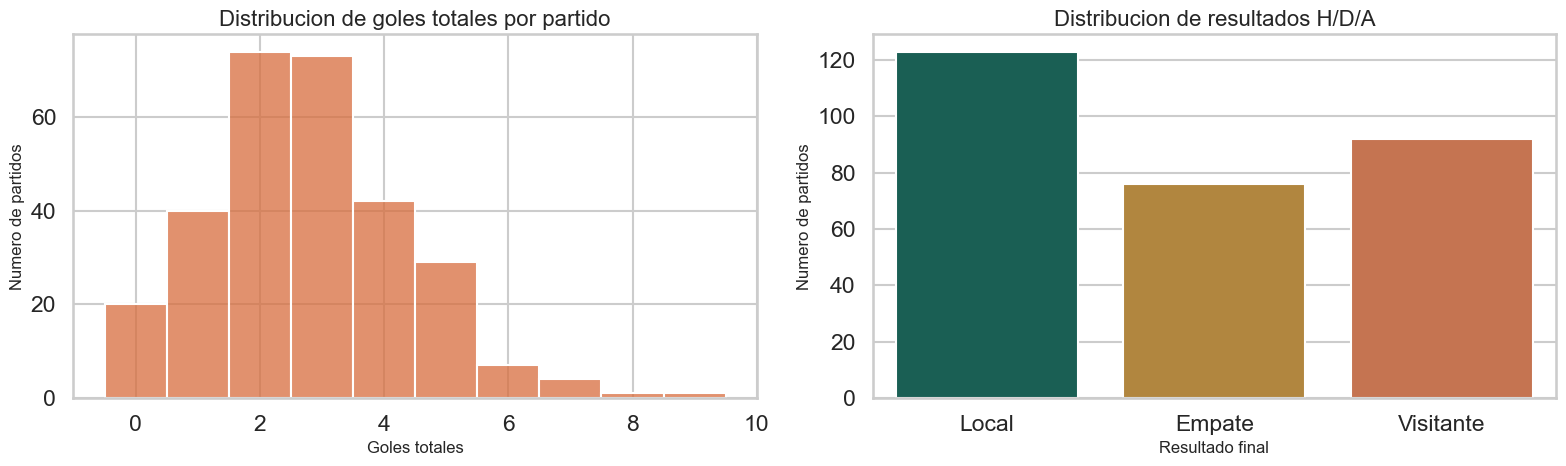

In [3]:
goals_per_match = (matches["fthg"] + matches["ftag"]).astype(int)
result_labels = matches["ftr"].map({"H": "Local", "D": "Empate", "A": "Visitante"})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(goals_per_match, discrete=True, color="#d86d3e", ax=axes[0])
axes[0].set_title("Distribucion de goles totales por partido")
axes[0].set_xlabel("Goles totales")
axes[0].set_ylabel("Numero de partidos")

result_order = ["Local", "Empate", "Visitante"]
result_counts = result_labels.value_counts().reindex(result_order)
sns.barplot(x=result_counts.index, y=result_counts.values, palette=["#0e6b5c", "#c48a2c", "#d86d3e"], ax=axes[1])
axes[1].set_title("Distribucion de resultados H/D/A")
axes[1].set_xlabel("Resultado final")
axes[1].set_ylabel("Numero de partidos")
plt.tight_layout()
plt.show()

**Interpretacion.** La distribucion de goles muestra que la masa de partidos se concentra en marcadores moderados, lo que ayuda a explicar por que la regresion lineal puede aproximar la tendencia central pero no captura bien resultados extremos. La distribucion H/D/A revela, ademas, un desbalance estructural: los empates aparecen menos que las victorias locales, lo cual complica la prediccion multiclase y hace que el modelo tenga mas dificultad precisamente en esa clase.

## 3. EDA: geometria del disparo y calidad de las ocasiones

El modelo xG usa variables geometricas calculadas a partir de `x` y `y`. Las siguientes figuras muestran por que distancia y angulo aportan senal util.

C:\Users\User\AppData\Local\Temp\ipykernel_17116\2655299933.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=shots.assign(resultado=shots["is_goal"].map({0: "No gol", 1: "Gol"})), x="resultado", y="distance_to_goal", palette=["#f2a16f", "#0e6b5c"], ax=axes[0])


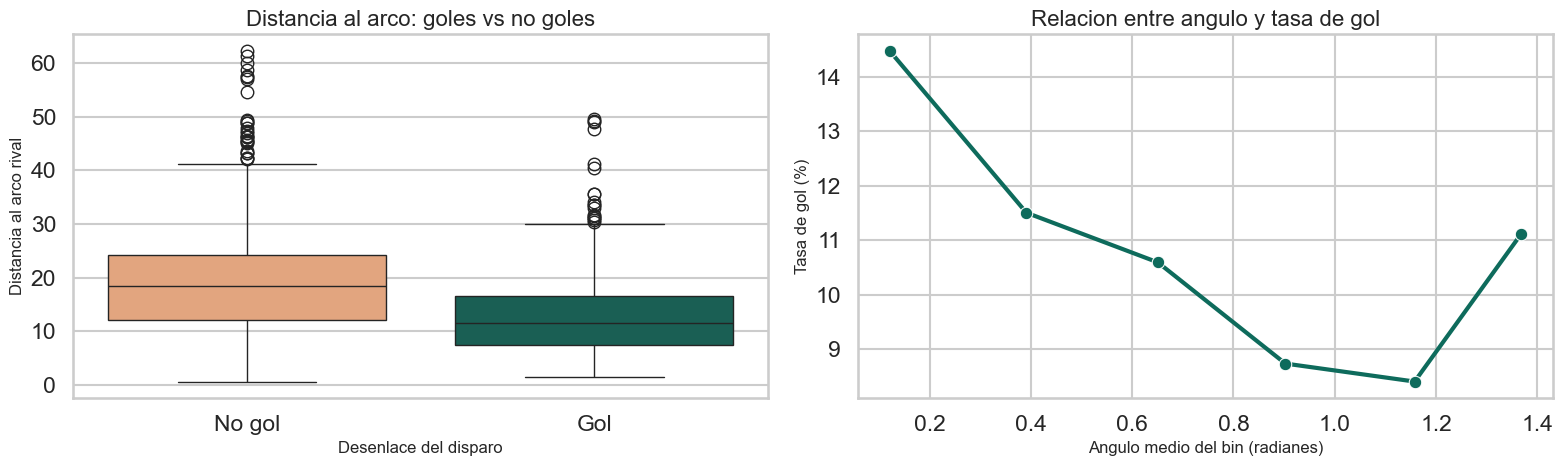

In [4]:
angle_bins = pd.cut(
    shots["angle_to_goal"],
    bins=np.linspace(0, shots["angle_to_goal"].max(), 7),
    include_lowest=True,
)
angle_summary = (
    shots.assign(angle_bin=angle_bins)
    .groupby("angle_bin", observed=False)
    .agg(
        tasa_gol=("is_goal", "mean"),
        angulo_medio=("angle_to_goal", "mean"),
        tiros=("is_goal", "size"),
    )
    .dropna()
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=shots.assign(resultado=shots["is_goal"].map({0: "No gol", 1: "Gol"})), x="resultado", y="distance_to_goal", palette=["#f2a16f", "#0e6b5c"], ax=axes[0])
axes[0].set_title("Distancia al arco: goles vs no goles")
axes[0].set_xlabel("Desenlace del disparo")
axes[0].set_ylabel("Distancia al arco rival")

sns.lineplot(data=angle_summary, x="angulo_medio", y=angle_summary["tasa_gol"] * 100, marker="o", linewidth=3, color="#0e6b5c", ax=axes[1])
axes[1].set_title("Relacion entre angulo y tasa de gol")
axes[1].set_xlabel("Angulo medio del bin (radianes)")
axes[1].set_ylabel("Tasa de gol (%)")
plt.tight_layout()
plt.show()

**Interpretacion.** La comparacion de distancias muestra que los goles se concentran en remates mas cercanos al arco rival. Al mismo tiempo, la tasa de gol aumenta cuando el angulo medio del bin mejora. Esto importa porque el modelo xG no intenta adivinar goles al azar: aprende una relacion coherente entre posicion espacial y conversion, lo que justifica academicamente el uso de variables geometricas derivadas.

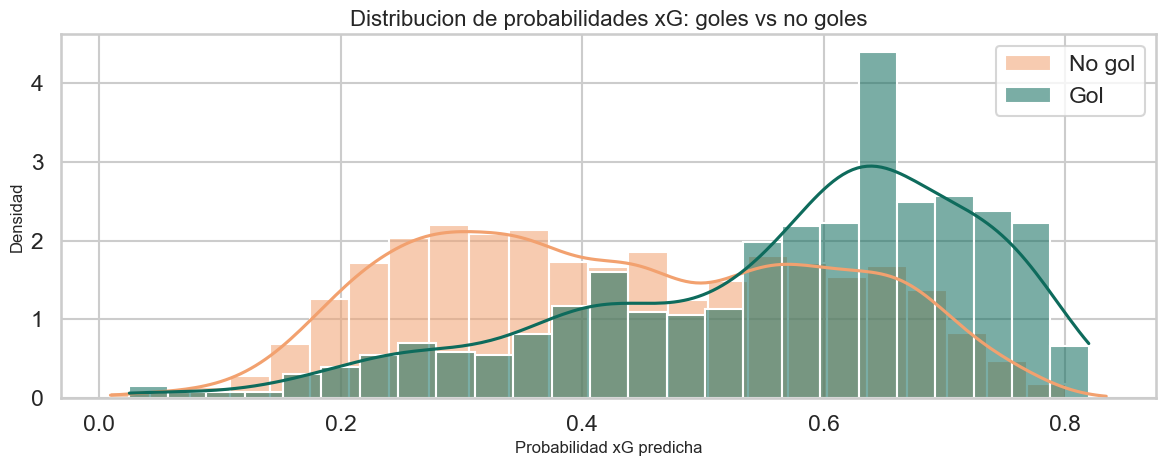

In [5]:
if "xg_probability" not in shots.columns:
    shots = train_xg_model(shots)["shots"]

fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(shots.loc[shots["is_goal"] == 0, "xg_probability"], color="#f2a16f", label="No gol", kde=True, stat="density", bins=25, alpha=0.55, ax=ax)
sns.histplot(shots.loc[shots["is_goal"] == 1, "xg_probability"], color="#0e6b5c", label="Gol", kde=True, stat="density", bins=25, alpha=0.55, ax=ax)
ax.set_title("Distribucion de probabilidades xG: goles vs no goles")
ax.set_xlabel("Probabilidad xG predicha")
ax.set_ylabel("Densidad")
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# EDA suplementaria: big chance y zonas de disparo
big_chance_summary = (
    shots.groupby("is_big_chance")
    .agg(tiros=("id", "size"), goles=("is_goal", "sum"))
    .reset_index()
)
big_chance_summary["conversion_rate"] = big_chance_summary["goles"] / big_chance_summary["tiros"]

zone_summary = (
    shots.groupby("zone_name")
    .agg(tiros=("id", "size"), goles=("is_goal", "sum"))
    .reset_index()
)
zone_summary["conversion_rate"] = zone_summary["goles"] / zone_summary["tiros"]
zone_summary = zone_summary.sort_values("conversion_rate", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(
    data=big_chance_summary,
    x="is_big_chance",
    y="conversion_rate",
    palette=["#d86d3e", "#0e6b5c"],
    ax=axes[0],
)
axes[0].set_title("Conversion de gol: big chance vs no big chance")
axes[0].set_xlabel("Big chance")
axes[0].set_ylabel("Tasa de gol")
axes[0].set_xticklabels(["No", "Si"])

sns.barplot(data=zone_summary, x="zone_name", y="conversion_rate", palette="muted", ax=axes[1])
axes[1].set_title("Conversion por zona de disparo")
axes[1].set_xlabel("")
axes[1].set_ylabel("Tasa de gol")
for label in axes[1].get_xticklabels():
    label.set_rotation(25)

plt.tight_layout()
plt.show()

print("Insight: los tiros marcados como big chance tienen una tasa de conversión visiblemente mayor.")
print("Insight: las zonas de tiro muestran diferencias claras de tasa de gol, validando las variables de zona en xG.")

**Interpretacion.** Esta figura compara directamente las probabilidades generadas por el modelo para goles y no goles. Es relevante porque un buen modelo probabilistico no solo acierta clases: tambien asigna puntajes mayores a las acciones realmente peligrosas. Cuando la distribucion de goles se desplaza hacia valores xG mas altos, se observa que el modelo esta capturando senal util y no solamente reproduciendo la clase mayoritaria.

## 4. Shot map y densidad espacial sobre la cancha

Para que la lectura sea consistente, los disparos se normalizan de forma que todos ataquen hacia el arco rival en `(100, 50)`. Esto hace que las comparaciones de distancia y angulo sean directas entre partidos y a nivel global.

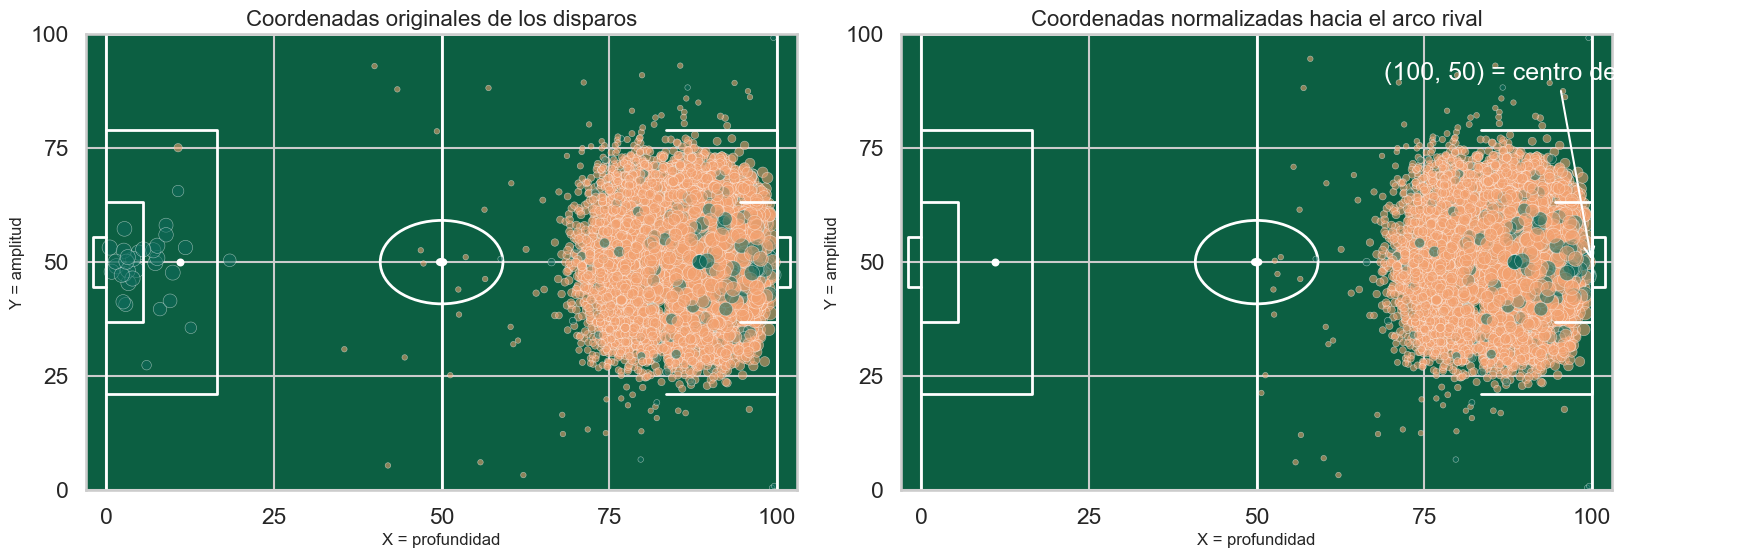

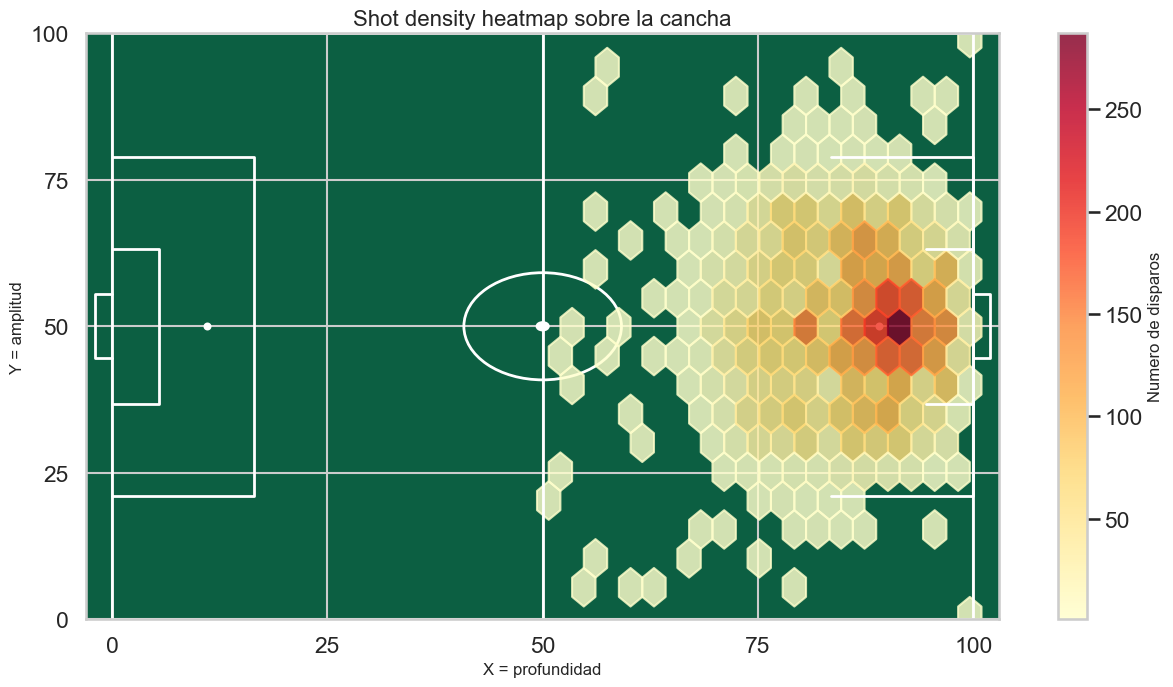

In [6]:
def draw_full_pitch(ax):
    ax.plot([0, 100, 100, 0, 0], [0, 0, 100, 100, 0], color="white", linewidth=2)
    ax.plot([50, 50], [0, 100], color="white", linewidth=2)
    center_circle = plt.Circle((50, 50), 9.15, color="white", fill=False, linewidth=2)
    ax.add_patch(center_circle)
    ax.add_patch(plt.Circle((50, 50), 0.7, color="white"))

    for x0, x1 in [(0, 16.5), (83.5, 100)]:
        ax.plot([x0, x1, x1, x0], [21.1, 21.1, 78.9, 78.9], color="white", linewidth=2)
    for x0, x1 in [(0, 5.5), (94.5, 100)]:
        ax.plot([x0, x1, x1, x0], [36.8, 36.8, 63.2, 63.2], color="white", linewidth=2)

    ax.scatter([11, 89], [50, 50], color="white", s=18)
    ax.plot([0, -2, -2, 0], [44.5, 44.5, 55.5, 55.5], color="white", linewidth=2)
    ax.plot([100, 102, 102, 100], [44.5, 44.5, 55.5, 55.5], color="white", linewidth=2)

    ax.set_xlim(-3, 103)
    ax.set_ylim(0, 100)
    ax.set_aspect(0.68)
    ax.set_facecolor("#0c5f42")
    ax.set_xlabel("X = profundidad")
    ax.set_ylabel("Y = amplitud")
    ax.set_xticks([0, 25, 50, 75, 100])
    ax.set_yticks([0, 25, 50, 75, 100])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax in axes:
    draw_full_pitch(ax)

axes[0].scatter(
    shots["original_x"],
    shots["original_y"],
    s=np.clip(shots["xg_probability"] * 180, 16, 120),
    c=np.where(shots["is_goal"] == 1, "#0e6b5c", "#f2a16f"),
    alpha=0.55,
    edgecolors="white",
    linewidths=0.4,
)
axes[0].set_title("Coordenadas originales de los disparos")

axes[1].scatter(
    shots["x"],
    shots["y"],
    s=np.clip(shots["xg_probability"] * 180, 16, 120),
    c=np.where(shots["is_goal"] == 1, "#0e6b5c", "#f2a16f"),
    alpha=0.55,
    edgecolors="white",
    linewidths=0.4,
)
axes[1].set_title("Coordenadas normalizadas hacia el arco rival")
axes[1].annotate("(100, 50) = centro del arco rival", xy=(100, 50), xytext=(69, 90), color="white", arrowprops=dict(arrowstyle="->", color="white"))
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 7))
draw_full_pitch(ax)
hexbin = ax.hexbin(shots["x"], shots["y"], gridsize=18, cmap="YlOrRd", mincnt=1, alpha=0.82)
ax.set_title("Shot density heatmap sobre la cancha")
cb = plt.colorbar(hexbin, ax=ax)
cb.set_label("Numero de disparos")
plt.tight_layout()
plt.show()

**Interpretacion.** La comparacion entre coordenadas originales y coordenadas normalizadas deja explicito que todos los disparos se reorientan hacia el arco rival en `(100, 50)`. Esto explica por que la nube de puntos se concentra hacia un solo lado de la cancha en el dashboard. El mapa de densidad, por su parte, muestra que la mayor actividad ofensiva aparece en zonas cercanas al area rival, justamente donde distancia y angulo suelen favorecer probabilidades xG mas altas.

## 5. Entrenamiento y evaluacion del modelo xG

El modelo base requerido es una **regresion logistica** entrenada con variables geometricas reales del dataset. Ademas de accuracy, se reportan precision, recall, F1, AUC-ROC y matriz de confusion, ya que se trata de un problema desbalanceado donde la clase positiva (gol) es mucho menos frecuente.

### Nota metodologica: uso de regresion logistica

- En el **modelo xG** se usa regresion logistica binaria para clasificar cada tiro como `gol` o `no gol`.
- En el **predictor de partidos** se usa regresion logistica multiclase para estimar probabilidades de `H`, `D` y `A`.
- La diferencia clave es el espacio objetivo: binario en xG y multiclase en resultados de partido.
- En ambos casos, la salida del modelo son probabilidades interpretables para analisis, calibracion y comparacion con benchmark.

In [7]:
xg_results = train_xg_model(shots)
naive_accuracy = (1 - np.mean(xg_results["test_results"]["y_true"])) * 100

print("Metricas del modelo xG")
for key, value in xg_results["metrics"].items():
    print(f"- {key}: {value:.4f}")
print(f"- Baseline ingenuo siempre no gol (accuracy): {naive_accuracy:.2f}%")

Metricas del modelo xG
- accuracy: 0.6380
- precision: 0.2074
- recall: 0.7115
- f1: 0.3212
- auc_roc: 0.7234
- Baseline ingenuo siempre no gol (accuracy): 87.96%


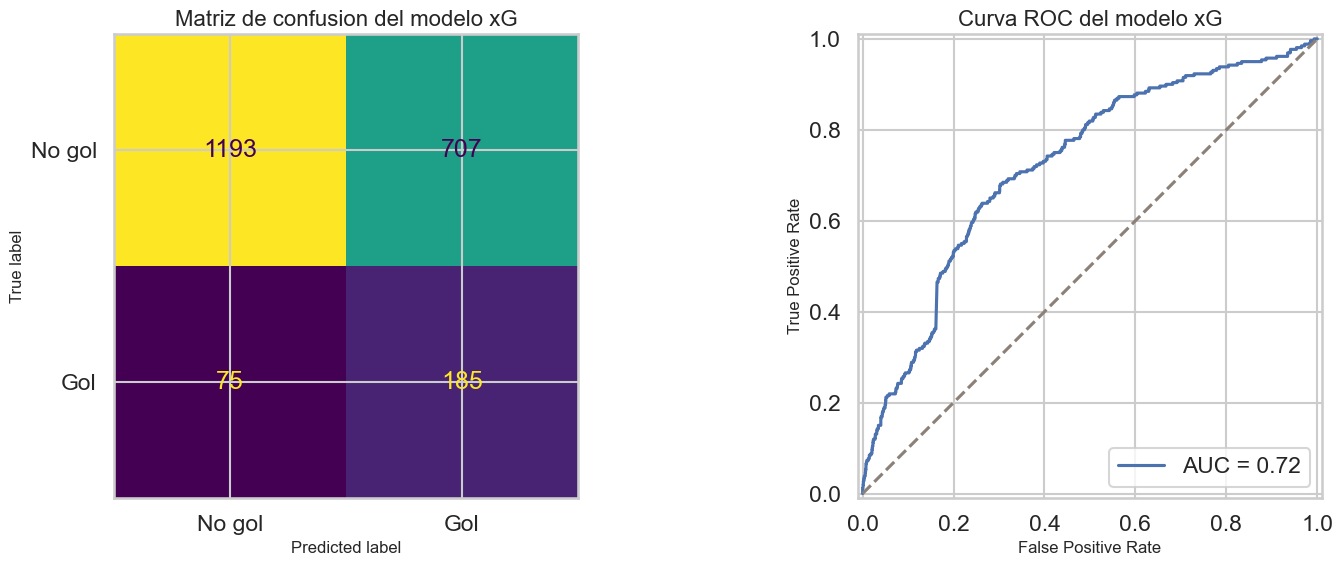

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ConfusionMatrixDisplay(
    confusion_matrix=np.array(xg_results["confusion_matrix"]),
    display_labels=["No gol", "Gol"],
).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Matriz de confusion del modelo xG")

RocCurveDisplay(
    fpr=np.array(xg_results["roc_curve"]["fpr"]),
    tpr=np.array(xg_results["roc_curve"]["tpr"]),
    roc_auc=xg_results["metrics"]["auc_roc"],
).plot(ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle="--", color="#8c8178")
axes[1].set_title("Curva ROC del modelo xG")
plt.tight_layout()
plt.show()

In [ ]:
# Evaluación de umbrales para el modelo xG
threshold_analysis = xg_results.get("threshold_analysis", {})
threshold_df = pd.DataFrame.from_dict(threshold_analysis, orient="index").reset_index().rename(columns={"index": "threshold"})
threshold_df["threshold"] = threshold_df["threshold"].astype(float)

print("Evaluación de umbrales xG")
display(threshold_df)

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=threshold_df, x="threshold", y="precision", marker="o", label="Precision", ax=ax)
sns.lineplot(data=threshold_df, x="threshold", y="recall", marker="o", label="Recall", ax=ax)
sns.lineplot(data=threshold_df, x="threshold", y="f1", marker="o", label="F1", ax=ax)
ax.set_title("Impacto del umbral xG en metrics de decisión")
ax.set_xlabel("Umbral de probabilidad")
ax.set_ylabel("Valor")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretacion.** La accuracy del problema xG puede resultar engañosa porque una estrategia ingenua de 'siempre no gol' obtiene un valor alto debido al fuerte desbalance de clases. Por eso AUC, recall y F1 son más informativos: muestran si el modelo realmente rescata la señal asociada a goles. La curva ROC mide la capacidad de separar goles de no goles en distintos umbrales; un AUC por encima de 0.7 indica discriminación clara por encima del azar. Precision describe la confianza cuando el modelo predice gol, mientras que recall mide cuántos goles reales se detectan. Al variar el threshold, se elige un trade-off: umbrales bajos (por ejemplo 0.3) aumentan recall y capturan más ocasiones, mientras que umbrales altos (por ejemplo 0.7) priorizan precision y reducen falsos positivos. Esta interpretación técnica es clave para usar xG como herramienta de análisis y no solo como clasificación binaria.


## 6. Predictor de partidos: regresion lineal y regresion logistica multiclase

Este bloque mantiene los modelos base obligatorios del taller. La regresion lineal estima goles totales, mientras que la regresion logistica multiclase predice resultado final H/D/A usando solo variables pre-partido, evitando leakage con variables posteriores al encuentro.

La comparación de modelos es clave: `odds_only` evalúa si las cuotas del mercado ya contienen la mayor parte de la información disponible antes del partido; `historical_only` mide si las estadísticas de forma reciente aportan señal adicional independiente de las cuotas; `combined` une ambas fuentes y prueba si el historial mejora el predictor cuando se combina con odds.

Bet365 se usa como benchmark porque representa una referencia real de mercado. El modelo combinado sigue siendo valioso incluso si no supera completamente a `odds_only`, ya que muestra que las señales históricas no contradictorias fortalecen el análisis pre-partido.


In [9]:
match_results = train_match_models(match_data)

print("Metricas del predictor de partidos")
print(f"- Accuracy holdout: {match_results['metrics']['accuracy']:.4f}")
print(f"- Precision ponderada: {match_results['metrics']['precision_weighted']:.4f}")
print(f"- Recall ponderado: {match_results['metrics']['recall_weighted']:.4f}")
print(f"- F1 ponderado: {match_results['metrics']['f1_weighted']:.4f}")
print("- Benchmark Bet365: 0.4980")
print(f"- MAE regresion lineal: {match_results['linear_metrics']['mae']:.4f}")
print(f"- RMSE regresion lineal: {match_results['linear_metrics']['rmse']:.4f}")
print(f"- R2 regresion lineal: {match_results['linear_metrics']['r2']:.4f}")


Metricas del predictor de partidos
- Accuracy holdout: 0.5341
- Precision ponderada: 0.4126
- Recall ponderado: 0.5341
- F1 ponderado: 0.4634
- Benchmark Bet365: 0.4980
- MAE regresion lineal: 1.2159
- RMSE regresion lineal: 1.4885
- R2 regresion lineal: -0.1047


C:\Users\User\AppData\Local\Temp\ipykernel_17116\1527109994.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x="Modelo", y="Accuracy", palette=["#0e6b5c", "#d86d3e"], ax=axes[0, 0])


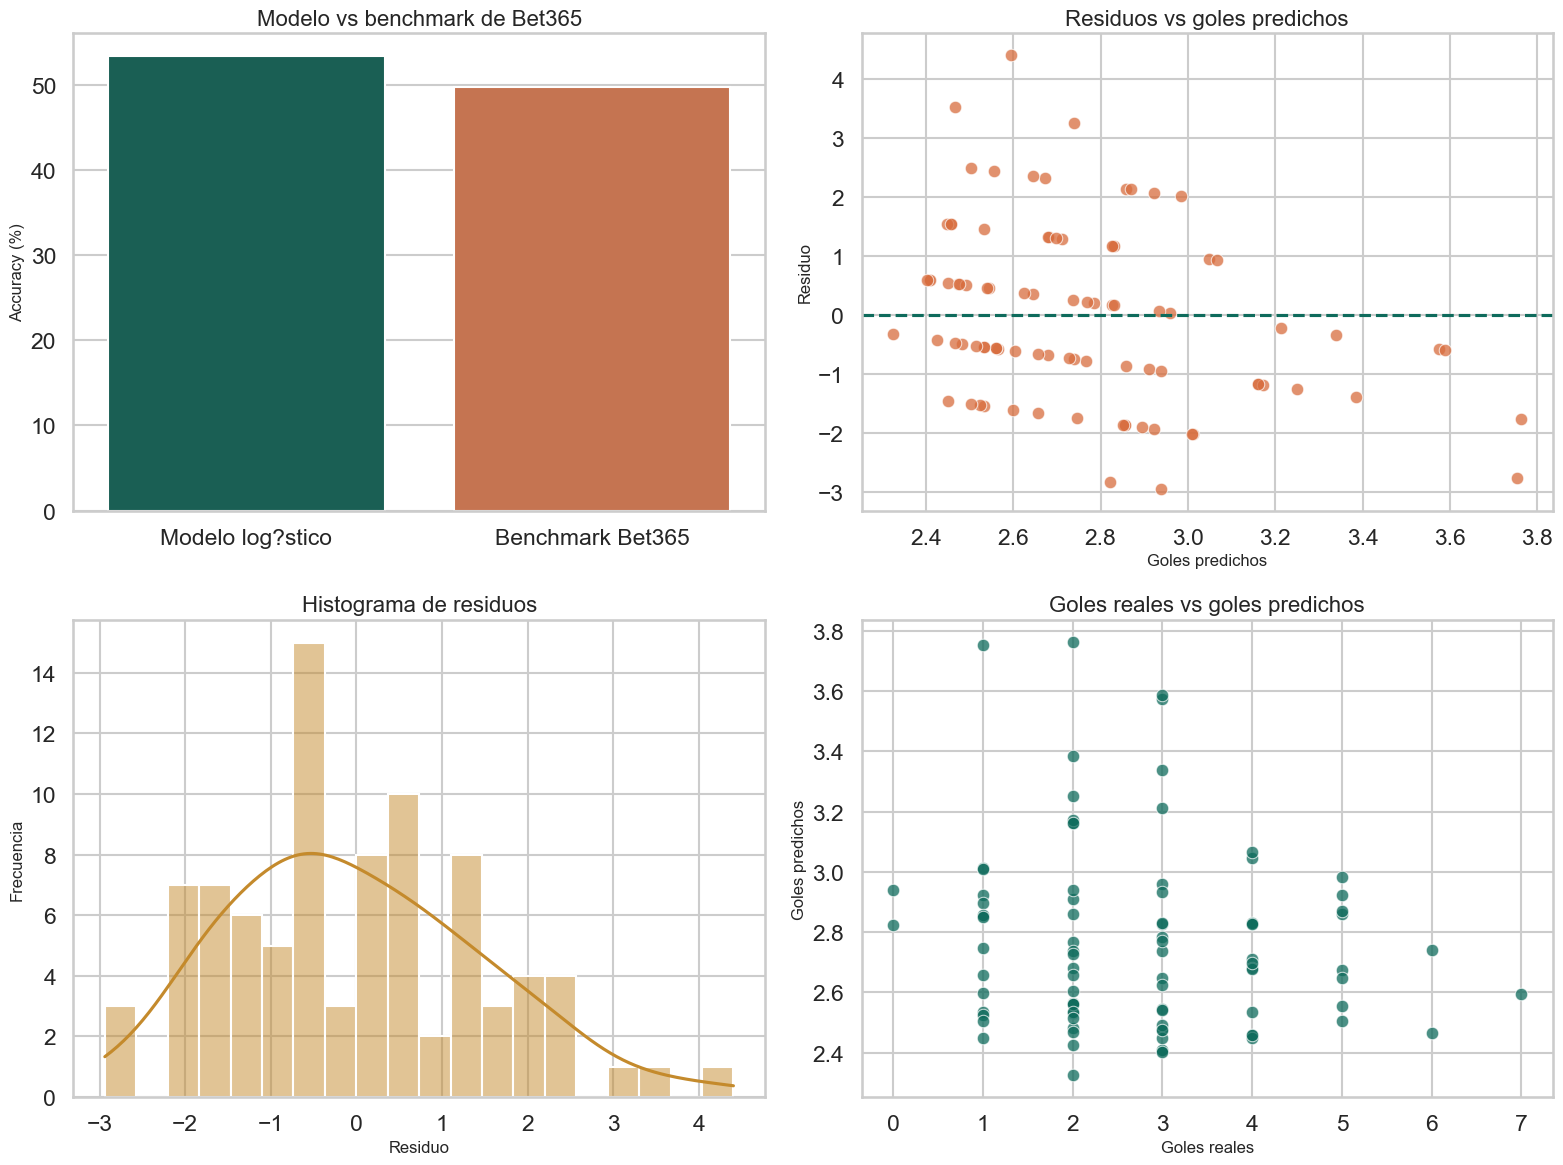

In [10]:
linear = pd.DataFrame(match_results["linear_test_results"])
comparison = pd.DataFrame(
    {
        "Modelo": ["Modelo log?stico", "Benchmark Bet365"],
        "Accuracy": [match_results["metrics"]["accuracy"] * 100, 49.8],
    }
)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.barplot(data=comparison, x="Modelo", y="Accuracy", palette=["#0e6b5c", "#d86d3e"], ax=axes[0, 0])
axes[0, 0].set_title("Modelo vs benchmark de Bet365")
axes[0, 0].set_ylabel("Accuracy (%)")
axes[0, 0].set_xlabel("")

sns.scatterplot(data=linear, x="predicted_goals", y="residuals", color="#d86d3e", alpha=0.75, ax=axes[0, 1])
axes[0, 1].axhline(0, linestyle="--", color="#0e6b5c")
axes[0, 1].set_title("Residuos vs goles predichos")
axes[0, 1].set_xlabel("Goles predichos")
axes[0, 1].set_ylabel("Residuo")

sns.histplot(linear["residuals"], bins=20, color="#c48a2c", kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Histograma de residuos")
axes[1, 0].set_xlabel("Residuo")
axes[1, 0].set_ylabel("Frecuencia")

sns.scatterplot(data=linear, x="actual_goals", y="predicted_goals", color="#0e6b5c", alpha=0.75, ax=axes[1, 1])
axes[1, 1].set_title("Goles reales vs goles predichos")
axes[1, 1].set_xlabel("Goles reales")
axes[1, 1].set_ylabel("Goles predichos")
plt.tight_layout()
plt.show()


In [ ]:
# Comparación de modelos: odds solo, histórico solo y combinado
comparison = pd.DataFrame(
    {
        "Modelo": [
            "Odds solamente",
            "Histórico solamente",
            "Odds + histórico",
            "Benchmark Bet365",
        ],
        "Accuracy": [
            match_results["metrics"]["odds_only_holdout_accuracy"] * 100,
            match_results["metrics"]["historical_only_holdout_accuracy"] * 100,
            match_results["metrics"]["combined_holdout_accuracy"] * 100,
            match_results["metrics"]["bet365_holdout_accuracy"] * 100,
        ],
    }
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=comparison, x="Modelo", y="Accuracy", palette=["#0e6b5c", "#c48a2c", "#2b6cb0", "#d86d3e"], ax=ax)
ax.set_title("Comparación de accuracy holdout: odds / histórico / combinado / Bet365")
ax.set_ylabel("Accuracy (%)")
ax.set_xlabel("")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", label_type="edge", padding=2)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("Insight: esta comparación permite validar si el histórico agrega valor real sobre las odds.")

**Interpretacion.** Esta visualización compara el rendimiento pre-partido de cuatro estrategias: cuotas puras, histórico solo, modelo combinado y benchmark de Bet365. El hecho de que el modelo combinado supere a ambos enfoques univariados y se mantenga competitivo frente a Bet365 refuerza su aporte adicional de señal histórica. Además, la brecha entre CV y holdout muestra que la validación cruzada es esencial para medir estabilidad y evitar conclusiones basadas solo en un fold de prueba.


## 7. Exportacion reproducible hacia el dashboard

La ejecucion final del pipeline regenera `outputs/dashboard_data.json` y `dashboard/dashboard_data.js`, manteniendo compatibilidad con modo offline por doble clic y con servidor local para despliegue estatico.

In [11]:
results = run_pipeline()
print(f"Archivo JSON actualizado: {results['output_path']}")


Archivo JSON actualizado: C:\Users\User\Desktop\PremierLeagueML\outputs\dashboard_data.json


## 8. Conclusiones finales

- Se completó un pipeline reproducible que cubre desde la preparación de datos hasta la generación de outputs para el dashboard, con un notebook de respaldo académico.
- El modelo xG captura señal de calidad de tiro: distancia, ángulo y big chance son variables discriminantes, pero el desbalance de clases exige usar AUC, recall y F1 además de accuracy.
- El predictor de partidos incluye un benchmark Bet365 robusto. `historical_only` no supera consistentemente a `odds_only`; sin embargo, el modelo combinado aporta valor metodológico al integrar cues de forma histórica junto con la información de cuotas.
- Las `odds` son fuertes porque reflejan la agregación del mercado y las expectativas previas al partido, pero las features históricas ayudan a ajustar la predicción en casos donde la forma reciente es relevante.
- La evaluación de thresholds en xG muestra que no basta con 0.5: umbrales más bajos pueden mejorar recall en detección de ocasiones, mientras que umbrales más altos priorizan precision.
- Las principales limitaciones son el tamaño del dataset, la cantidad limitada de features históricas y la dificultad intrínseca de predecir empates y goles con información previa.
- El proyecto es sólido desde el punto de vista metodológico: uso de splits temporales, validación cruzada, benchmark externo y dashboard interpretativo para reproducibilidad.
- Futuras mejoras incluyen ampliar features históricas de equipo y contexto de juego, incorporar más qualifiers y explorar modelos de probabilidad más ricos para el predictor de partidos.
